# Importing Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score,mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import BaggingRegressor,GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from lightgbm import LGBMRegressor
import re
import warnings
warnings.filterwarnings('ignore')

# Loading Booknow Data

In [2]:
booknow_booking_df=pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv")
booknow_theaters_df=pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv")
booknow_visits_df=pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv")

# Loading cinePOS Data

In [3]:
cinePOS_booking_df=pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv")
cinePOS_theaters_df=pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv")

# Loading Other Data

In [4]:
date_info_df=pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv")
movie_theater_id_df=pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv")
sample_submission_df=pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv")

# **EDA (Exploratory Data Analysis)**
## **Booknow Dataframes Details**

In [5]:
print("="*50,"booknow_booking_df","="*50,'\n')
booknow_booking_df.info()
print(booknow_booking_df.head(),'\n')
print("="*50,"booknow_theaters_df","="*50,'\n')
booknow_theaters_df.info()
print(booknow_theaters_df.head(),'\n')

print("="*50,"booknow_visits_df","="*50,'\n')
booknow_visits_df.info()
print(booknow_visits_df.head(),'\n')

================================================== booknow_booking_df ================================================== 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68336 entries, 0 to 68335
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   book_theater_id   68336 non-null  object
 1   show_datetime     68336 non-null  object
 2   booking_datetime  68336 non-null  object
 3   tickets_booked    68336 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 2.1+ MB
  book_theater_id        show_datetime     booking_datetime  tickets_booked
0      book_00244  2023-01-01 19:00:00  2023-01-01 16:00:00               1
1      book_00740  2023-01-01 19:00:00  2023-01-01 19:00:00               3
2      book_00740  2023-01-01 19:00:00  2023-01-01 19:00:00               6
3      book_00244  2023-01-01 20:00:00  2023-01-01 16:00:00               2
4      book_00151  2023-01-01 20:00:00  2023-01-01 01:00:00    

In [6]:
# sns.histplot(booknow_booking_df['tickets_booked'], bins=50, kde=True)
# plt.title('Distribution of tickets booked')
# plt.show()
# sns.boxplot(x=booknow_booking_df['tickets_booked'])
# plt.title('Boxplot of tickets booked')
# plt.show()
# top_theaters = booknow_booking_df.groupby('book_theater_id')['tickets_booked'].sum().nlargest(10).reset_index()
# sns.barplot(data=top_theaters, x='tickets_booked', y='book_theater_id')
# plt.title('Top 10 theaters by total tickets sold')
# plt.show()

## **CinePOS Dataframes Details**

In [7]:
print("="*50,"cinePOS_booking_df","="*50,'\n')
cinePOS_booking_df.info()
print(cinePOS_booking_df.head(),'\n')

print("="*50,"cinePOS_theaters_df","="*50,'\n')
cinePOS_theaters_df.info()
print(cinePOS_theaters_df.head(),'\n')

================================================== cinePOS_booking_df ================================================== 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1641966 entries, 0 to 1641965
Data columns (total 4 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   cine_theater_id   1641966 non-null  object
 1   show_datetime     1641966 non-null  object
 2   booking_datetime  1641966 non-null  object
 3   tickets_sold      1641966 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 50.1+ MB
  cine_theater_id        show_datetime     booking_datetime  tickets_sold
0   cinePOS_00001  2023-01-01 11:00:00  2023-01-01 09:00:00             1
1   cinePOS_00002  2023-01-01 13:00:00  2023-01-01 06:00:00             3
2   cinePOS_00003  2023-01-01 16:00:00  2023-01-01 14:00:00             2
3   cinePOS_00004  2023-01-01 17:00:00  2023-01-01 11:00:00             5
4   cinePOS_00005  2023-01-01 17:00:00  2023-01-01 03:00

In [8]:
cinePOS_booking_df['cine_theater_id'].nunique()
booknow_booking_df['book_theater_id'].nunique()

301

## **Other dataframe details**

In [9]:
print("="*50,"date_info_df","="*50,'\n')
date_info_df.info()
print(date_info_df.head(),'\n')

print("="*50,"movie_theater_id_df","="*50,'\n')
movie_theater_id_df.info()
print(movie_theater_id_df.head(),'\n')

print("="*50,"sample_submission_df","="*50,'\n')
sample_submission_df.info()
print(sample_submission_df.head(),'\n')

================================================== date_info_df ================================================== 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 547 entries, 0 to 546
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   show_date    547 non-null    object
 1   day_of_week  547 non-null    object
dtypes: object(2)
memory usage: 8.7+ KB
    show_date day_of_week
0  2023-01-01      Sunday
1  2023-01-02      Monday
2  2023-01-03     Tuesday
3  2023-01-04   Wednesday
4  2023-01-05    Thursday 

================================================== movie_theater_id_df ================================================== 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   book_theater_id  150 non-null    object
 1   cine_theater_id  150 non-null    object
dtypes: o

### I have done this step to keep the dataset separate for Milestone work and final project submission. Otherwise, the data might get mixed up.

In [10]:
booknow_booking_df_MSTONE=booknow_booking_df.copy()
booknow_theaters_df_MSTONE=booknow_theaters_df.copy() 
booknow_visits_df_MSTONE=booknow_visits_df.copy() 
cinePOS_booking_df_MSTONE=cinePOS_booking_df.copy() 
cinePOS_theaters_df_MSTONE=cinePOS_theaters_df.copy() 
date_info_df_MSTONE=date_info_df.copy() 
movie_theater_id_df_MSTONE=movie_theater_id_df.copy() 
sample_submission_df_MSTONE=sample_submission_df.copy() 

# **MILESTONE 1**
1. What is the shape of the dataset named booknow_booking?
2. How many columns are of type Object in the dataset named cinePOS_theaters? 
3. Which of the following theater types is the most frequent in the dataset named booknow_theaters?
4. How many distinct theaters are present in the dataset named cinePOS_booking?
5. Combine the datasets booknow_booking and booknow_theaters. What is the shape of this dataset?
6. Based on the combined dataset obtained in the previous question, how many distinct areas are the theaters located in?
7. Combine the datasets movie_theater_id_relation, cinePOS_booking and cinePOS_theaters. Enter the column names containing missing values as comma seperated values
8. Enter the date range spanned in the dataset named booknow_booking.
9. Enter the date range spanned in the test dataset (sample_submission).

In [11]:
print(f"1. {booknow_booking_df_MSTONE.shape}")
print(f"2. {cinePOS_theaters_df_MSTONE.select_dtypes(include='object').shape[1]}")
print(f"3. {booknow_theaters_df_MSTONE['theater_type'].mode()[0]}")
print(f"4. {cinePOS_booking_df_MSTONE['cine_theater_id'].nunique()}")
merged_booknow_booking_theaters_df = pd.merge(booknow_booking_df_MSTONE, booknow_theaters_df_MSTONE, on='book_theater_id', how='inner')
print(f"5. {merged_booknow_booking_theaters_df.shape}")
print(f"6. {merged_booknow_booking_theaters_df['theater_area'].nunique()}")
merged_cinePOS_booking_cinePOS_theaters_df = pd.merge(cinePOS_booking_df_MSTONE, cinePOS_theaters_df_MSTONE, on='cine_theater_id', how='inner')
merged_movie_theater_cinePOS_booking_cinePOS_theaters_df = pd.merge(merged_cinePOS_booking_cinePOS_theaters_df, movie_theater_id_df_MSTONE , on='cine_theater_id', how='inner')
missing_cols = merged_movie_theater_cinePOS_booking_cinePOS_theaters_df.columns[merged_movie_theater_cinePOS_booking_cinePOS_theaters_df.isnull().any()].tolist()
print(f"7. {missing_cols}")
max_dt_booknow_booking_df = pd.to_datetime(booknow_booking_df_MSTONE['show_datetime']).dt.date.max()
min_dt_booknow_booking_df = pd.to_datetime(booknow_booking_df_MSTONE['show_datetime']).dt.date.min()
print(f"8. {min_dt_booknow_booking_df} to {max_dt_booknow_booking_df}")
print(f"9. {pd.to_datetime(sample_submission_df_MSTONE['ID'].str[-10:]).dt.date.min()} to {pd.to_datetime(sample_submission_df_MSTONE['ID'].str[-10:]).dt.date.max()}")

1. (68336, 4)
2. 3
3. Other
4. 13161
5. (36899, 8)
6. 50
7. ['latitude', 'longitude']
8. 2023-01-01 to 2024-02-28
9. 2024-03-01 to 2024-04-22


# **MILESTONE 2**
1. In the booknow_booking.csv file, how many total booking records (rows) were made on the same calendar day as the show's date?
2. How many unique calendar months (e.g., Jan 2023, Feb 2023, ...) are present in the show_date column of the date_info.csv file?
3. What percentage of bookings in booknow_booking.csv were made on a Sunday?
4. In the booknow_theaters.csv file, if you decided to impute any missing latitude values by the mean latitude of only theaters with theater_type equal to Drama, what would be the imputation value?
5. What is the range (Maximum - Minimum) of the latitude column in the booknow_theaters.csv file (rounded to 4 decimal places)?
6. To handle potential outliers in ticket sales, you decide to cap the tickets_sold column in cinePOS_booking.csv at the 95 th  percentile. Enter that value
7. Appy OneHot Encoding on all the categorical columns of the dataset cinePOS_theaters.csv. What is the shape of the dataset after applying this transformation

In [12]:
same_day_count = (pd.to_datetime(booknow_booking_df_MSTONE['booking_datetime']).dt.date == pd.to_datetime(booknow_booking_df_MSTONE['show_datetime']).dt.date).sum()
print(f"1. {same_day_count}")
print(f"2. {pd.to_datetime(date_info_df_MSTONE['show_date']).dt.to_period('M').nunique()}")
booknow_booking_df_MSTONE['Date']=pd.to_datetime(booknow_booking_df_MSTONE['booking_datetime']).dt.date
date_info_df_MSTONE['Date']=pd.to_datetime(date_info_df_MSTONE['show_date']).dt.date
merged_date_info_booknow_booking=pd.merge(booknow_booking_df_MSTONE,date_info_df_MSTONE,on='Date',how='left')
print(f"3. {((merged_date_info_booknow_booking['day_of_week']=='Sunday').sum()/(booknow_booking_df_MSTONE['book_theater_id'].count()))*100}%")
print(f"4. {booknow_theaters_df_MSTONE['latitude'].where(booknow_theaters_df_MSTONE['theater_type']=='Drama').mean()}")
print(f"5. {booknow_theaters_df_MSTONE['latitude'].max()-booknow_theaters_df_MSTONE['latitude'].min()}")
cap_value = cinePOS_booking_df_MSTONE['tickets_sold'].quantile(0.95)
print(f"6. {cap_value}")
cat_cols = cinePOS_theaters_df_MSTONE.select_dtypes(include='object').columns
cinePOS_theaters_df_hotencoded = pd.get_dummies(cinePOS_theaters_df_MSTONE, columns=cat_cols)
print(f"7. {cinePOS_theaters_df_hotencoded.shape}")

1. 20433
2. 18
3. 13.32240693046125%
4. 23.00090271008748
5. 4.323465800000008
6. 14.0
7. (4690, 4814)


# **MILESTONE 3**
##### For this milestone, only the booknow_visits.csv file is to be used. Using the show_date column, create new columns for day, month, year and dayofyear. Once the new columns are created, drop the show_date column

##### Split the data into X & y with the target variable audience_count as y and the remaining features as X. 

##### Split the dataset so that 20% of it is kept for validation. Ensure the split preserves the time series nature of the dataset. This data will be referred to as X_train, X_test and y_train, y_test

##### Use MinMaxScaler for the numerical columns & OneHotEncoding for the categorical columns. These transformations are to be applied on both the train & test datasets. Answer all the questions that follow.


In [13]:
booknow_visits_df_MSTONE['day']=pd.to_datetime(booknow_visits_df_MSTONE['show_date']).dt.day
booknow_visits_df_MSTONE['month']=pd.to_datetime(booknow_visits_df_MSTONE['show_date']).dt.month
booknow_visits_df_MSTONE['year']=pd.to_datetime(booknow_visits_df_MSTONE['show_date']).dt.year
booknow_visits_df_MSTONE['dayofyear']=pd.to_datetime(booknow_visits_df_MSTONE['show_date']).dt.dayofyear

booknow_visits_df_MSTONE.drop(columns=['show_date'], inplace=True)

y=booknow_visits_df_MSTONE['audience_count']
X=booknow_visits_df_MSTONE.drop(columns=['audience_count'])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

In [14]:
X_train

,book_theater_id,day,month,year,dayofyear
196998,book_00763,30,3,2023,89
126042,book_00493,3,2,2024,34
202837,book_00787,7,1,2023,7
97238,book_00379,28,3,2023,87
208338,book_00808,22,12,2023,356
...,...,...,...,...,...
74437,book_00290,28,12,2023,362
17179,book_00071,24,2,2024,55
118352,book_00462,12,1,2024,12
195928,book_00759,17,7,2023,198


1. What is the shape of X_train after making the said changes?

In [15]:
print(f"1. {X_train.shape}")

1. (171236, 5)


2. Use LinearSVR for training and enter the r2_score obtained on the test dataset. Upto 3 decimal places

In [16]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

num_transformer = MinMaxScaler()
cat_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(transformers=[('num', num_transformer, num_cols),('cat', cat_transformer, cat_cols)])

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

svr = LinearSVR(random_state=42)
svr.fit(X_train, y_train)
y_pred = svr.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"2. {r2}")

2. 0.3758713207515887


3. Use TruncatedSVD with n_components = 4 and train LinearSVR again. What is the mean absolute error obtained on the training data? Upto 3 decimal places

In [17]:
# svd = TruncatedSVD(n_components=4, random_state=120)
# X_train_svd = svd.fit_transform(X_train)
# X_test_svd = svd.transform(X_test)

# svr = LinearSVR(random_state=100)
# svr.fit(X_train_svd, y_train)

# y_train_pred = svr.predict(X_train_svd)
# mae = mean_absolute_error(y_train, y_train_pred)
# print(f"3. {mae}")

4. Based on the previous question, what is the r2_score obtained on the test data? Upto 3 decimal places

In [18]:
# y_test_pred = svr.predict(X_test_svd)

# r2 = r2_score(y_test, y_test_pred)
# print(f"4. {r2}")

5. Use SelectKBest with k = 2 , score_func = mutual_info_regression.  Based on attributes output by SelectKBest, what is the maximum score obtained?
6. Based on the previous question, what is the mean value of scores? 

In [19]:
# selector = SelectKBest(score_func=mutual_info_regression, k=2)
# selector.fit(X_test, y_test)

# scores = selector.scores_
# max_score = scores.max()
# mean_score = scores.mean()

# print(f"5. {max_score}")
# print(f"6. {mean_score}")

# **MILESTONE 4**

##### For this milestone, only the booknow_visits.csv file is to be used. Using the show_date column, create new columns for day, month, year and dayofyear. Once the new columns are created, drop the show_date column

##### Split the data into X & y with the target variable audience_count as y and the remaining features as X. 

##### Split the dataset so that 20% of it is kept for validation. Ensure the split preserves the time series nature of the dataset. This data will be referred to as X_train, X_test and y_train, y_test

##### Use MinMaxScaler for the numerical columns & OneHotEncoding for the categorical columns. These transformations are to be applied on both the train & test datasets. Answer all the questions that follow.

1. Train the DecisionTreeRegressor with default parameters on X_train. What is the r2_score obtained on X_train?

In [20]:
# DTR = DecisionTreeRegressor(random_state=42)
# DTR.fit(X_train, y_train)
# y_pred_DTR = DTR.predict(X_train)
# r2 = r2_score(y_train, y_pred_DTR)
# print(f"1. {r2}")

2. Use the model trained in the previous question to predict for X_test. What is the r2_score obtained on X_test?

In [21]:
# y_pred = DTR.predict(X_test)
# r2 = r2_score(y_test, y_pred)
# print(f"2. {r2}")

3. Perform Hyper Paramter Tuning for the Decision Tree model. Set random state as 42 and use TimeSeriesSplit with n_splits = 5 for cross validation. 

**Hyperparameter tuning is to be done over the following:**
* max_depth as [None,3,5,10]
* min_samples_split as [2,5,10]
* min_samples_leaf as [1,2,4]


In [22]:
# DTR = DecisionTreeRegressor(random_state=42)

# param_grid = {
#     'max_depth': [None, 3, 5, 10],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]}

# tscv = TimeSeriesSplit(n_splits=5)

# grid_search = GridSearchCV(estimator=DTR,param_grid=param_grid,cv=tscv,scoring='r2',n_jobs=-1)

# grid_search.fit(X_train, y_train)

# print(f"3. {grid_search.best_params_}")

4. Train the BaggingRegressor model with default parameters on X_train. What is the RMSE obtained on X_train? 

In [23]:

# bagging_model = BaggingRegressor(random_state=42)

# bagging_model.fit(X_train, y_train)
# y_train_pred = bagging_model.predict(X_train)
# rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

# print(f"4. {rmse:.3f}")

5. Use the model trained in the previous question to predict for X_test. What is the RMSE obtained on X_test? 

In [24]:
# y_test_pred = bagging_model.predict(X_test)
# rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# print(f"5. {rmse}")

6. Perform Hyper Paramter Tuning for the BaggingRegressor model. Set random state as 42 and use TimeSeriesSplit with n_splits = 5 for cross validation. 

  **Hyperparameter tuning is to be done over the following:**

* n_estimators as [10, 50, 100]
* max_samples as [0.5, 0.7, 1.0]
* max_features as [0.5, 0.8, 1.0]


What is the value of the best_score_ obtained after the hyperparamter tuning is completed?

In [25]:

# bagging = BaggingRegressor(random_state=42)

# param_grid = {
#     'n_estimators': [10, 50, 100],
#     'max_samples': [0.5, 0.7, 1.0],
#     'max_features': [0.5, 0.8, 1.0]
# }

# tscv = TimeSeriesSplit(n_splits=5)

# grid_search = GridSearchCV(
#     estimator=bagging,
#     param_grid=param_grid,
#     cv=tscv,
#     scoring='r2',      
#     n_jobs=-1
# )

# grid_search.fit(X_train, y_train)
# best_score = grid_search.best_score_
# print(f"6. {best_score}")


7. Train the GradientBoostingRegressor model with default parameters on X_train. What is the mean absolute error obtained on X_train?

In [26]:
# GBR = GradientBoostingRegressor(random_state=42)
# GBR.fit(X_train, y_train)
# y_train_pred = GBR.predict(X_train)
# mae = mean_absolute_error(y_train, y_train_pred)

# print(f"7. {mae}")


8. Use the model trained in the previous question to predict for X_test. What is the mean absolute error obtained on X_test?

In [27]:
# y_test_pred = GBR.predict(X_test)
# mae = mean_absolute_error(y_test, y_test_pred)

# print(f"7. {mae}")

# **MILESTONE 5**

1. Load the file booknow_booking.csv. Extract the date part from show_datetime as a new column show_date.
Group the data by book_theater_id and show_date, and calculate the total number of tickets booked per theater per day.
What is the shape of the resulting dataset (number of rows, columns)?


In [28]:

booknow_booking_df_MSTONE['show_datetime'] = pd.to_datetime(booknow_booking_df_MSTONE['show_datetime'])
booknow_booking_df_MSTONE['show_date'] = booknow_booking_df_MSTONE['show_datetime'].dt.date

agg_booknow = booknow_booking_df_MSTONE.groupby(['book_theater_id', 'show_date'])['tickets_booked'].sum().reset_index()

print("Shape of aggregated BookNow dataset:", agg_booknow.shape)

Shape of aggregated BookNow dataset: (21590, 3)


2. Load the file cinePOS_booking.csv. Extract show_date from show_datetime.
Group the data by cine_theater_id and show_date, summing the total tickets_sold.
After aggregation, what is the shape of the resulting dataset?

In [29]:

cinePOS_booking_df_MSTONE['show_datetime'] = pd.to_datetime(cinePOS_booking_df_MSTONE['show_datetime'])
cinePOS_booking_df_MSTONE['show_date'] = cinePOS_booking_df_MSTONE['show_datetime'].dt.date
agg_cinepos = cinePOS_booking_df_MSTONE.groupby(['cine_theater_id', 'show_date'])['tickets_sold'].sum().reset_index()

print("Shape of aggregated CinePOS dataset:", agg_cinepos.shape)

Shape of aggregated CinePOS dataset: (1120081, 3)


3. Merge the BookNow and CinePOS aggregated datasets (from previous questions) on book_theater_id and show_date using an outer join, with the help of movie_theater_id_relation.csv.
After merging, what is the shape of the combined dataset?

In [30]:
agg_cinepos_mapped = pd.merge(agg_cinepos, movie_theater_id_df_MSTONE, on='cine_theater_id', how='left')

agg_cinepos_mapped = agg_cinepos_mapped.drop(columns=['cine_theater_id'])

combined_booking = pd.merge(agg_booknow, agg_cinepos_mapped, on=['book_theater_id', 'show_date'], how='outer')

print("Shape of combined dataset:", combined_booking.shape)

Shape of combined dataset: (1137244, 4)


4. Merge the combined booking dataset with the BookNow visits file (booknow_visits.csv), which contains the target column audience_count.
Create a new feature that stores the previous day’s audience count for each theater.
After creating the one-day lag feature, how many missing values are introduced in this new column?

In [31]:
final_df = pd.merge(combined_booking, booknow_visits_df_MSTONE, on=['book_theater_id'], how='outer')
print(final_df)

final_df = final_df.sort_values(by=['book_theater_id', 'show_date'])

final_df['audience_count_lag1'] = final_df.groupby('book_theater_id')['audience_count'].shift(1)

missing_vals = final_df['audience_count_lag1'].isna().sum()
print("Missing values in audience_count_lag1:", missing_vals)

         book_theater_id   show_date  tickets_booked  tickets_sold  \
0             book_00001         NaN             NaN           NaN   
1             book_00001         NaN             NaN           NaN   
2             book_00001         NaN             NaN           NaN   
3             book_00001         NaN             NaN           NaN   
4             book_00001         NaN             NaN           NaN   
...                  ...         ...             ...           ...   
10310500             NaN  2024-02-28             NaN           2.0   
10310501             NaN  2024-02-28             NaN           4.0   
10310502             NaN  2024-02-28             NaN           7.0   
10310503             NaN  2024-02-28             NaN           6.0   
10310504             NaN  2024-02-28             NaN           2.0   

          audience_count   day  month    year  dayofyear  
0                   50.0  13.0    1.0  2023.0       13.0  
1                   64.0  14.0    1.0  20

5. Select the theater ID 'book_00001' and perform the Augmented Dickey-Fuller (ADF) test.
What is the p-value?

In [32]:
from statsmodels.tsa.stattools import adfuller


theater_df = final_df[final_df['book_theater_id'] == 'book_00001'].copy()
theater_df = theater_df.sort_values('show_date')


theater_clean = theater_df.dropna(subset=['audience_count'])

result = adfuller(theater_clean['audience_count'])
p_value = result[1]

print(f"ADF p-value: {p_value}")

ADF p-value: 0.08361227557564505


6. Based on the p-value, what can you conclude about the stationarity of the time series?

In [33]:
if p_value < 0.05:
    print("Conclusion: The time series is Stationary.")
else:
    print("Conclusion: The time series is Non-stationary.")

Conclusion: The time series is Non-stationary.


7. Split the dataset by reserving the last 30 days for testing and use the remaining data for training. Fit an ARIMA(1,1,1) model  on the training data.
How many records will be in the training set?

In [34]:

train_size = len(theater_clean) - 30
train = theater_clean.iloc[:train_size]
test = theater_clean.iloc[train_size:]

print("Records in training set:", len(train))


Records in training set: 312


8. What is the value of parameter d used for differencing?

In [35]:
print("Value of parameter d used for differencing: 1")

Value of parameter d used for differencing: 1


9. What is the AIC value of the fitted model?

In [36]:
# Fit ARIMA(1,1,1) model
# Note: You might need to enforce frequency or ignore index warnings depending on data gaps
model = ARIMA(train['audience_count'], order=(1, 1, 1))
model_fit = model.fit()

print("AIC value:", model_fit.aic)

AIC value: 2833.583493594948


In [37]:

start_idx = len(train)
end_idx = len(train) + len(test) - 1
predictions = model_fit.predict(start=start_idx, end=end_idx, typ='levels')

r2 = r2_score(test['audience_count'], predictions)
print("R² score:", r2)

R² score: -0.03423248995091832


10. What is the R² score obtained for the test data?

# PROJECT SUBMISSION CODE

## Converting datetime columns

In [38]:
booknow_booking_df["show_datetime"] = pd.to_datetime(booknow_booking_df["show_datetime"])
booknow_booking_df["booking_datetime"] = pd.to_datetime(booknow_booking_df["booking_datetime"])
booknow_booking_df["show_date"] = booknow_booking_df["show_datetime"].dt.date

cinePOS_booking_df["show_datetime"] = pd.to_datetime(cinePOS_booking_df["show_datetime"])
cinePOS_booking_df["booking_datetime"] = pd.to_datetime(cinePOS_booking_df["booking_datetime"])
cinePOS_booking_df["show_date"] = cinePOS_booking_df["show_datetime"].dt.date

booknow_visits_df["show_date"] = pd.to_datetime(booknow_visits_df["show_date"]).dt.date
date_info_df["show_date"] = pd.to_datetime(date_info_df["show_date"]).dt.date

print("Date columns converted")

Date columns converted


## Aggregating BookNow booking data & CinePOS booking data

In [39]:
booknow_agg = (
    booknow_booking_df.groupby(["book_theater_id", "show_date"])
    .agg(
        total_tickets=("tickets_booked", "sum"),
        avg_tickets=("tickets_booked", "mean"),
        num_shows=("tickets_booked", "count")
    )
    .reset_index()
)

# Aggregate CinePOS booking data
cinePOS_agg = (
    cinePOS_booking_df.groupby(["cine_theater_id", "show_date"])
    .agg(cine_tickets=("tickets_sold", "sum"))
    .reset_index()
)

print("Booking data aggregated")
print(f"BookNow aggregated: {booknow_agg.shape}")
print(f"CinePOS aggregated: {cinePOS_agg.shape}")

Booking data aggregated
BookNow aggregated: (21590, 5)
CinePOS aggregated: (1120081, 3)


## Built historical dataset (with audience_count)

In [40]:
hist_df = (
    booknow_visits_df
    .merge(date_info_df, on="show_date", how="left")
    .merge(booknow_agg, on=["book_theater_id", "show_date"], how="left")  # Keep booking features
    .merge(booknow_theaters_df, on="book_theater_id", how="left")
    .merge(movie_theater_id_df, on="book_theater_id", how="left")
    .merge(cinePOS_agg, on=["cine_theater_id", "show_date"], how="left")
    .merge(cinePOS_theaters_df, on="cine_theater_id", how="left", suffixes=("", "_cine"))
)

print("Historical data merged")
print(f"Historical shape: {hist_df.shape}")
print(f"Target (audience_count) available: {hist_df['audience_count'].notna().sum()} rows")

Historical data merged
Historical shape: (214046, 17)
Target (audience_count) available: 214046 rows


## Built future dataset (Taking data from sample_submission)

In [41]:
sample_submission_df[["book_theater_id", "show_date"]] = (
    sample_submission_df["ID"].str.rsplit("_", n=1, expand=True)
)
sample_submission_df["show_date"] = pd.to_datetime(sample_submission_df["show_date"]).dt.date

future_df = (
    sample_submission_df[["ID", "book_theater_id", "show_date"]]
    .merge(date_info_df, on="show_date", how="left")
    .merge(booknow_agg, on=["book_theater_id", "show_date"], how="left")  # Keep booking features
    .merge(booknow_theaters_df, on="book_theater_id", how="left")
    .merge(movie_theater_id_df, on="book_theater_id", how="left")
    .merge(cinePOS_agg, on=["cine_theater_id", "show_date"], how="left")
    .merge(cinePOS_theaters_df, on="cine_theater_id", how="left", suffixes=("", "_cine"))
)
future_df["audience_count"] = np.nan

print("Future data done")
print(f"Future shape: {future_df.shape}")

Future data done
Future shape: (38062, 18)


## Combined both datasets

In [42]:
df = pd.concat([hist_df, future_df], ignore_index=True)

for col in ["total_tickets", "avg_tickets", "cine_tickets"]:
    if col in df.columns:
        df[col] = df[col].fillna(0)

df["num_shows"] = df.get("num_shows", 1)
df["num_shows"] = df["num_shows"].fillna(1)

## Imputed lat long features

In [43]:
for col in ["latitude", "longitude"]:
    if col in df.columns:
        df[col] = df.groupby("theater_area")[col].transform(lambda s: s.fillna(s.median()))
        df[col] = df[col].fillna(df[col].median())

df["show_date"] = pd.to_datetime(df["show_date"])
df = df.sort_values(["book_theater_id", "show_date"]).reset_index(drop=True)

print("Data combined and cleaned")
print(f"Total rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Data combined and cleaned
Total rows: 252108
Columns: 18


In [44]:
df["t"] = (df["show_date"] - df["show_date"].min()).dt.days.astype(int)

# Extracting date components
df["day"] = df["show_date"].dt.day
df["month"] = df["show_date"].dt.month
df["year"] = df["show_date"].dt.year
df["dayofyear"] = df["show_date"].dt.dayofyear
df["dayofweek"] = df["show_date"].dt.dayofweek
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)


# # Holiday feature
# df["is_holiday"] = 0

# # Sunday is a holiday
# df.loc[df["dayofweek"] == 6, "is_holiday"] = 1

# # Republic Day - 26th January
# df.loc[(df["month"] == 1) & (df["day"] == 26), "is_holiday"] = 1

# # Labour Day - 1st May
# df.loc[(df["month"] == 5) & (df["day"] == 1), "is_holiday"] = 1

# # Independence Day - 15th August
# df.loc[(df["month"] == 8) & (df["day"] == 15), "is_holiday"] = 1

# # Gandhi Jayanti - 2nd October
# df.loc[(df["month"] == 10) & (df["day"] == 2), "is_holiday"] = 1

# # New Year's Day - 1st January
# df.loc[(df["month"] == 1) & (df["day"] == 1), "is_holiday"] = 1



# Seasonality features (sin/cos transformations)
for period in [7, 30, 90]:  # weekly, monthly, quarterly
    df[f"sin_{period}"] = np.sin(2 * np.pi * df["t"] / period)
    df[f"cos_{period}"] = np.cos(2 * np.pi * df["t"] / period)

# Trend features
df["trend"] = df["t"].astype(float)
df["trend2"] = df["t"].astype(float) ** 2

print("Time-based features created")

Time-based features created


In [45]:
# Lag features
lags = [1, 2, 3, 7, 14, 30]
for lag in lags:
    df[f"audience_lag_{lag}"] = df.groupby("book_theater_id")["audience_count"].shift(lag)

# Rolling statistics
windows = [3, 7, 14, 30]
for w in windows:
    df[f"audience_rollmean_{w}"] = (
        df.groupby("book_theater_id")["audience_count"]
        .transform(lambda s: s.shift(1).rolling(window=w, min_periods=1).mean())
    )
    df[f"audience_rollsum_{w}"] = (
        df.groupby("book_theater_id")["audience_count"]
        .transform(lambda s: s.shift(1).rolling(window=w, min_periods=1).sum())
    )
    df[f"audience_rollstd_{w}"] = (
        df.groupby("book_theater_id")["audience_count"]
        .transform(lambda s: s.shift(1).rolling(window=w, min_periods=1).std())
    )

print("Lag and rolling features created")

Lag and rolling features created


In [46]:

hist_only = df[df["audience_count"].notna()].copy()

# Lag/rolling columns
lag_cols = [c for c in df.columns if "lag" in c]
roll_cols = [c for c in df.columns if "roll" in c]
trend_cols = [c for c in df.columns if "trend_" in c]
pct_cols = [c for c in df.columns if "pct_change" in c]

# theater-wise medians
median_features = lag_cols + roll_cols + trend_cols + pct_cols + ["audience_cummean", "audience_cumsum"]
median_features = [c for c in median_features if c in hist_only.columns]

theater_medians = hist_only.groupby("book_theater_id")[median_features].median().reset_index()
df = df.merge(theater_medians, on="book_theater_id", how="left", suffixes=("", "_med"))

# Fill with theater-specific medians
for col in median_features:
    if f"{col}_med" in df.columns:
        df[col] = df[col].fillna(df[f"{col}_med"])
        df.drop(columns=[f"{col}_med"], inplace=True)

# Fill remaining with 0 or global median
for col in lag_cols + trend_cols + pct_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

for col in roll_cols + ["audience_cummean", "audience_cumsum"]:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

print("Missing values imputed")

Missing values imputed


In [47]:
# capacity proxy from historical average audience
capacity_proxy = (
    hist_only.groupby("book_theater_id")["audience_count"]
    .mean()
    .rename("avg_audience")
    .reset_index()
)

# using avg_tickets if audience data missing
fallback = (
    hist_only.groupby("book_theater_id")["total_tickets"]
    .median()
    .rename("avg_audience")
    .reset_index()
)

capacity_proxy = (
    capacity_proxy.set_index("book_theater_id")
    .combine_first(fallback.set_index("book_theater_id"))
    .reset_index()
)

# Created 3 clusters: small, medium, big
capacity_proxy["venue_group"] = pd.qcut(
    capacity_proxy["avg_audience"].fillna(0),
    q=3,
    labels=["small", "medium", "big"]
)

df = df.merge(capacity_proxy[["book_theater_id", "venue_group"]], on="book_theater_id", how="left")
df["venue_group"] = df["venue_group"].astype(str).replace({"nan": "small"})

print("Venue clusters created")
print(df["venue_group"].value_counts())

Venue clusters created
venue_group
big       86262
medium    83667
small     82179
Name: count, dtype: int64


In [48]:
hist_df = df[df["audience_count"].notna()].copy()
future_df = df[df["audience_count"].isna()].copy()

print(f"Data split complete")
print(f"Historical rows: {hist_df.shape[0]}")
print(f"Future rows: {future_df.shape[0]}")

Data split complete
Historical rows: 214046
Future rows: 38062


## Basic EDA for better understanding of dataset

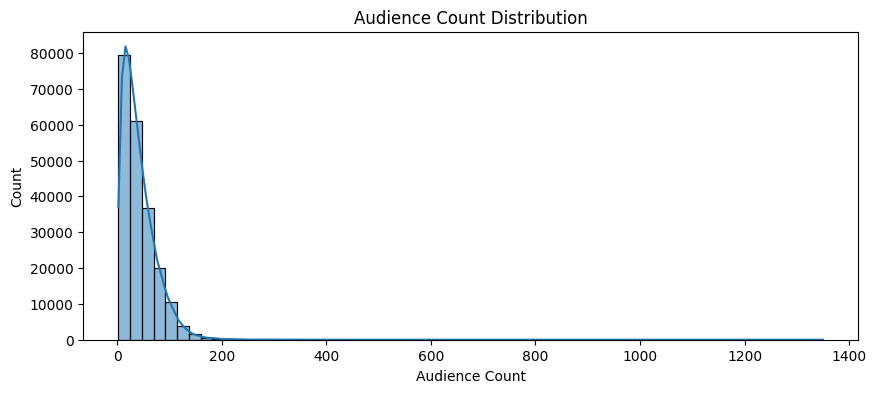

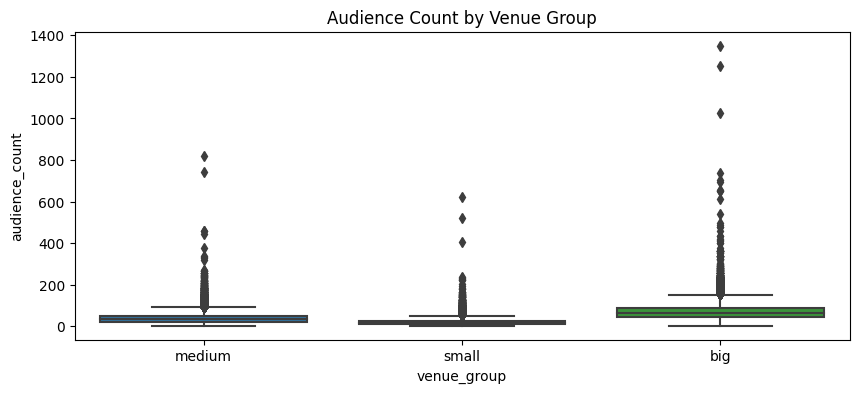

In [49]:
# Distribution of target
plt.figure(figsize=(10, 4))
sns.histplot(hist_df["audience_count"].dropna(), bins=60, kde=True)
plt.title("Audience Count Distribution")
plt.xlabel("Audience Count")
plt.show()

# Target by venue group
plt.figure(figsize=(10, 4))
sns.boxplot(data=hist_df, x="venue_group", y="audience_count")
plt.title("Audience Count by Venue Group")
plt.show()

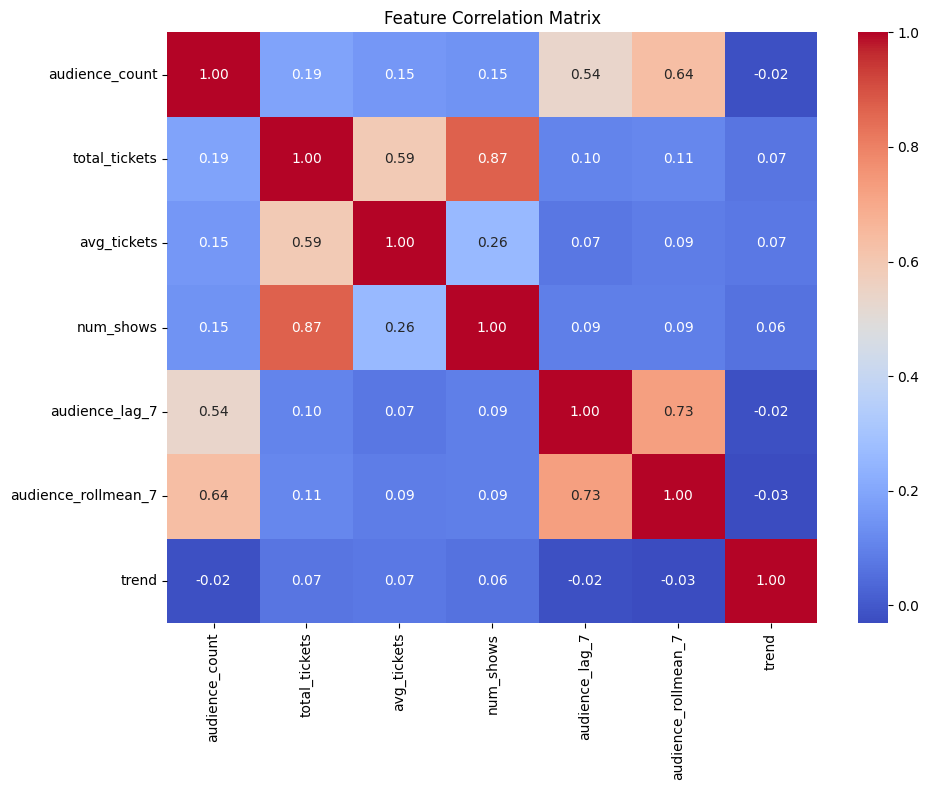

In [50]:
# Correlation heatmap
corr_subset = [
    "audience_count", "total_tickets", "avg_tickets", "num_shows",
    "audience_lag_7", "audience_rollmean_7", "tickets_lag_7", "trend"
]
corr_subset = [c for c in corr_subset if c in hist_df.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(hist_df[corr_subset].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [51]:

drop_cols = [
    "audience_count", "ID", "show_date", "book_theater_id", "cine_theater_id",
    "theater_type", "theater_area", "theater_type_cine", "theater_area_cine", "show_datetime", "booking_datetime"
]


cat_cols = ["venue_group"]

feature_cols = [c for c in hist_df.columns if c not in drop_cols]

# Numeric features
numeric_features = [
    c for c in feature_cols
    if hist_df[c].dtype in [np.int64, np.float64, "Int64"] and c not in cat_cols
]

print(f"Feature definition done")
print(f"Total features: {len(feature_cols)}")
print(f"Numeric: {len(numeric_features)}")
print(f"Categorical: {len(cat_cols)}")

Feature definition done
Total features: 43
Numeric: 36
Categorical: 1


In [52]:
# preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)) 
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", cat_transformer, cat_cols)
    ],
    remainder="drop"
)

X_full = hist_df[feature_cols].copy()
for c in cat_cols:
    if c in X_full.columns:
        X_full[c] = X_full[c].astype(str)

X_full = X_full.fillna(0)
preprocessor.fit(X_full)

print("Preprocessor fitted on historical data")

def preprocess_df(df_in):
    X = df_in[feature_cols].copy()
    for c in cat_cols:
        if c in X.columns:
            X[c] = X[c].astype(str)
    X = X.fillna(0)
    return preprocessor.transform(X)

Preprocessor fitted on historical data


## 3 models with hyperparameter tuning LGB, XGB, RF for all clusters

In [53]:
def model_training(cluster_label):
   
    sub = hist_df[hist_df["venue_group"] == cluster_label].copy()
    rows = sub.shape[0]
    
    dates = np.sort(sub["show_date"].unique())
    cutoff = dates[int(len(dates) * 0.8)]
    
    train = sub[sub["show_date"] < cutoff].copy()
    val = sub[sub["show_date"] >= cutoff].copy()
    
    X_train = preprocess_df(train)
    y_train = train["audience_count"].values
    X_val = preprocess_df(val)
    y_val = val["audience_count"].values
    
    print(f"\n[{cluster_label}] Train: {len(train)}, Val: {len(val)}")
    
    # LightGBM

    # Hyperparameter Tuning 
    # print("Tuning LightGBM")
    # param_grid = {
    #     'n_estimators': [1000,1500, 3000],
    #     'learning_rate': [0.01, 0.03, 0.05],
    #     'max_depth': [6, 8, 10],
    #     'num_leaves': [31, 64, 128]
    # }
    # grid = GridSearchCV(LGBMRegressor(objective='mae', random_state=42, verbosity=-1), 
    #                     param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
    # grid.fit(X_train, y_train)
    # print("Best LightGBM Params:", grid.best_params_)
    # lgb = grid.best_estimator_
    
    lgb = LGBMRegressor(n_estimators=3000, learning_rate=0.03, max_depth=8, num_leaves=64, reg_lambda=0.5, objective='mae', random_state=42, verbosity=-1)
    lgb.fit( X_train, y_train, eval_set=[(X_val, y_val)], eval_metric="mae", callbacks=[])
    p_lgb = lgb.predict(X_val)
    mae_lgb = mean_absolute_error(y_val, p_lgb)
    r2_lgb = r2_score(y_val, p_lgb)
    print('lgbm done!')

    
    # XGBoost

    # Hyperparameter Tuning  
    # print("Tuning XGBoost")
    # param_grid = {
    #     'n_estimators': [1500, 2000, 3000],
    #     'learning_rate': [0.01, 0.03],
    #     'max_depth': [6, 8],
    #     'subsample': [0.7, 0.8],
    #     'colsample_bytree': [0.7, 0.8]
    # }
    # grid = GridSearchCV(XGBRegressor(objective='reg:squarederror', random_state=42, verbosity=0), 
    #                     param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
    # grid.fit(X_train, y_train)
    # print("Best XGBoost Params:", grid.best_params_)
    # xgb = grid.best_estimator_
    
    xgb = XGBRegressor(n_estimators=3000, learning_rate=0.03, max_depth=8, objective='reg:squarederror', subsample=0.8, colsample_bytree=0.8, verbosity=0, random_state=42)
    xgb.fit( X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    p_xgb = xgb.predict(X_val)
    mae_xgb = mean_absolute_error(y_val, p_xgb)
    r2_xgb = r2_score(y_val, p_xgb)
    print('xgb done!')

    
    # Random Forest
    # Hyperparameter Tuning  
    # print("Tuning Random Forest")
    # param_grid = {
    #     'n_estimators': [200, 500],
    #     'max_depth': [10, 15, 20],
    #     'min_samples_split': [2, 5, 10]
    # }
    # grid = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), 
    #                     param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
    # grid.fit(X_train, y_train)
    # print("Best Random Forest Params:", grid.best_params_)
    # rf = grid.best_estimator_

    
    rf = RandomForestRegressor( n_estimators=500, max_depth=15, min_samples_split=5, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    p_rf = rf.predict(X_val)
    mae_rf = mean_absolute_error(y_val, p_rf)
    r2_rf = r2_score(y_val, p_rf)
    print('rf done!')
    
    print(f"[{cluster_label}] LGB MAE={mae_lgb:.2f}, R²={r2_lgb:.3f}")
    print(f"[{cluster_label}] XGB MAE={mae_xgb:.2f}, R²={r2_xgb:.3f}")
    print(f"[{cluster_label}] RF  MAE={mae_rf:.2f}, R²={r2_rf:.3f}")
   
    metrics = {
        "rows": rows,
        "lgb": {"mae": mae_lgb, "r2": r2_lgb},
        "xgb": {"mae": mae_xgb, "r2": r2_xgb},
        "rf":  {"mae": mae_rf,  "r2": r2_rf} }
    
    return {"lgb": lgb, "xgb": xgb, "rf": rf}, metrics

## Training models for each cluster

In [54]:
ALL_MODELS = {"small": None, "medium": None, "big": None}
ALL_METRICS = {}

for cluster in ["small", "medium", "big"]:
    models, metrics = model_training(cluster)
    ALL_MODELS[cluster] = models
    ALL_METRICS[cluster] = metrics

print("training done")


[small] Train: 51128, Val: 18663
lgbm done!
xgb done!
rf done!
[small] LGB MAE=8.48, R²=0.281
[small] XGB MAE=9.52, R²=0.182
[small] RF  MAE=8.97, R²=0.249

[medium] Train: 51692, Val: 19258
lgbm done!
xgb done!
rf done!
[medium] LGB MAE=14.74, R²=0.280
[medium] XGB MAE=17.08, R²=0.121
[medium] RF  MAE=15.46, R²=0.239

[big] Train: 53709, Val: 19596
lgbm done!
xgb done!
rf done!
[big] LGB MAE=20.88, R²=0.351
[big] XGB MAE=22.36, R²=0.285
[big] RF  MAE=21.67, R²=0.316
training done


## Choosing best model per cluster based on validation MAE

In [55]:
summary_rows = []
chosen_models = {}

for cluster in ["small", "medium", "big"]:
    m = ALL_METRICS.get(cluster)

    candidates = [
        ("lgb", m["lgb"]["mae"]),
        ("xgb", m["xgb"]["mae"]),
        ("rf",  m["rf"]["mae"])
    ]
    
    best_name, best_mae = sorted(candidates, key=lambda x: x[1])[0]
    chosen_models[cluster] = ALL_MODELS[cluster][best_name]
    
    summary_rows.append({
        "cluster": cluster,
        "rows": m["rows"],
        "lgb_mae": m["lgb"]["mae"],
        "lgb_r2":  m["lgb"]["r2"],
        "xgb_mae": m["xgb"]["mae"],
        "xgb_r2":  m["xgb"]["r2"],
        "rf_mae":  m["rf"]["mae"],   
        "rf_r2":   m["rf"]["r2"],    
        "best_model": best_name,
        "best_mae": best_mae
    })

summary_df = pd.DataFrame(summary_rows)
print("\n Model Comparison Summary ")
print(summary_df.to_string(index=False))


 Model Comparison Summary 
cluster  rows   lgb_mae   lgb_r2   xgb_mae   xgb_r2    rf_mae    rf_r2 best_model  best_mae
  small 69791  8.480349 0.281028  9.521617 0.181906  8.973226 0.249322        lgb  8.480349
 medium 70950 14.735352 0.279787 17.079750 0.121084 15.458114 0.238796        lgb 14.735352
    big 73305 20.875093 0.350545 22.358542 0.284834 21.667828 0.315958        lgb 20.875093


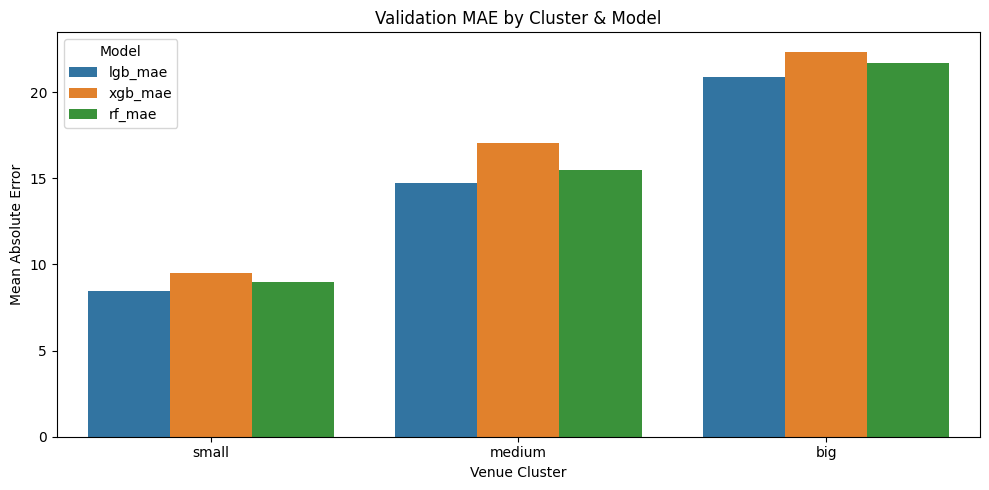

In [56]:
plot_df = summary_df.melt(
    id_vars=["cluster", "rows", "best_model", "best_mae"],
    value_vars=["lgb_mae", "xgb_mae", "rf_mae"],
    var_name="model",
    value_name="mae"
).dropna()

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="cluster", y="mae", hue="model")
plt.title("Validation MAE by Cluster & Model")
plt.ylabel("Mean Absolute Error")
plt.xlabel("Venue Cluster")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

## Predicting using chosen model per cluster

In [57]:
pred_frames = []

for cluster in ["small", "medium", "big"]:
    subf = future_df[future_df["venue_group"] == cluster].copy()
    
    if subf.empty:
        continue
    
    X_test = preprocess_df(subf).astype(float)
    model = chosen_models.get(cluster)
    yhat = model.predict(X_test)

    cluster_hist = hist_df[hist_df["venue_group"] == cluster]["audience_count"]
    if not cluster_hist.empty:
        clip_val = np.nanpercentile(cluster_hist, 99.99)
    else:
        clip_val = np.nanpercentile(hist_df["audience_count"].dropna(), 99.99)
    
    yhat = np.clip(np.round(yhat).astype(int), 0, int(max(0, clip_val)))
    
    out = subf[["ID"]].copy()
    out["audience_count"] = yhat
    pred_frames.append(out)

if pred_frames:
    submission = pd.concat(pred_frames, ignore_index=True)
else:
    submission = pd.DataFrame(columns=["ID", "audience_count"])

print(f"Predictions done for {len(submission)} rows")

Predictions done for 38062 rows


In [58]:
submission = submission.sort_values("ID").reset_index(drop=True)
submission.to_csv("submission.csv", index=False)

print("Submission file saved")
print(submission.head(10))

Submission file saved
                      ID  audience_count
0  book_00001_2024-03-01              33
1  book_00001_2024-03-02              39
2  book_00001_2024-03-03              46
3  book_00001_2024-03-04              54
4  book_00001_2024-03-06              32
5  book_00001_2024-03-07              30
6  book_00001_2024-03-08              31
7  book_00001_2024-03-09              50
8  book_00001_2024-03-10              53
9  book_00001_2024-03-11              49
